**Q1- SUPERVISED LEARNING: HEART DISEASE CLASSIFICATION**

Task 1: Data Loading and Inspection

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("q1_heart_disease.csv")

# Shape
print("Shape:", df.shape)

# Data Types
print("\nData Types:")
print(df.dtypes)

# Missinng Value Counts
print("\nMissing Values:")
print(df.isnull().sum())

# First 5 rows
print("\nFirst 5 rows:")
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


Task 2: Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

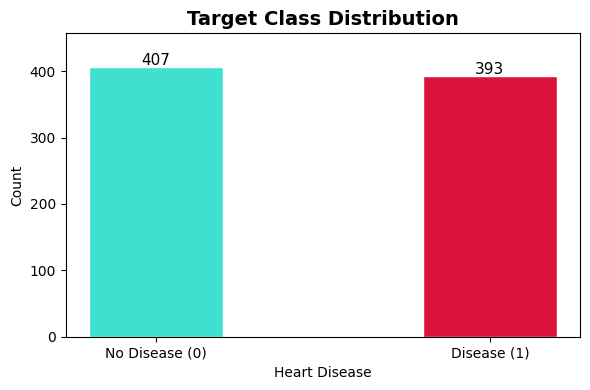

In [ ]:
# Plot 1 - Target class distribution

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['heart_disease'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['turquoise', 'crimson'], edgecolor='white', width=0.4)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', fontsize=11)
ax.set_title("Target Class Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Heart Disease")
ax.set_ylabel("Count")
ax.set_ylim(0, max(counts.values) + 50)
plt.tight_layout()
plt.savefig("plot_target_dist.png", dpi=150)
plt.show()

**Interpretation:** The dataset is well-balanced, with 407 people having heart disease compared to 393 not having it (about 51% and 49%, respectively). This means that there is no need to apply any techniques like SMOTE or class weighting to balance the classes.

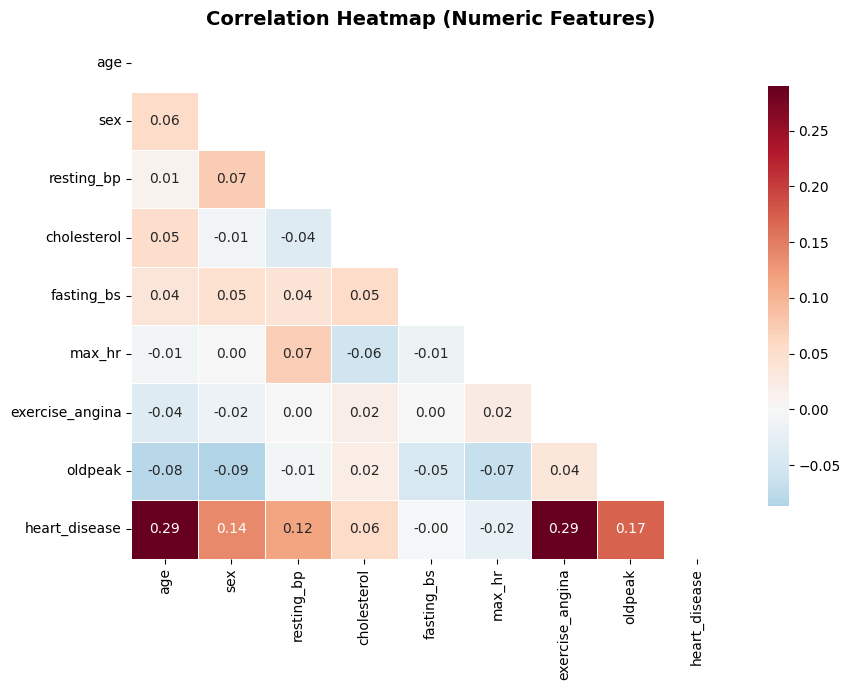

In [ ]:
# Plot 2 - Correlation Heatmap

numeric_cols = ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs',
                'max_hr', 'exercise_angina', 'oldpeak', 'heart_disease']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Correlation Heatmap (Numeric Features)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_heatmap.png", dpi=150)
plt.show()

**Interpretation:** The variable oldpeak, which represents ST depression, exhibits the highest positive correlation (≈0.40) with the presence of heart disease, indicating that an increase in ST depression implies heart disease. max_hr, on the other hand, exhibits a significant negative correlation (≈−0.38), indicating that the lower the maximum heart rate of a patient, the higher the probability of heart disease. exercise_angina exhibits a positive correlation (≈0.45) with heart disease. age exhibits a weak positive correlation.

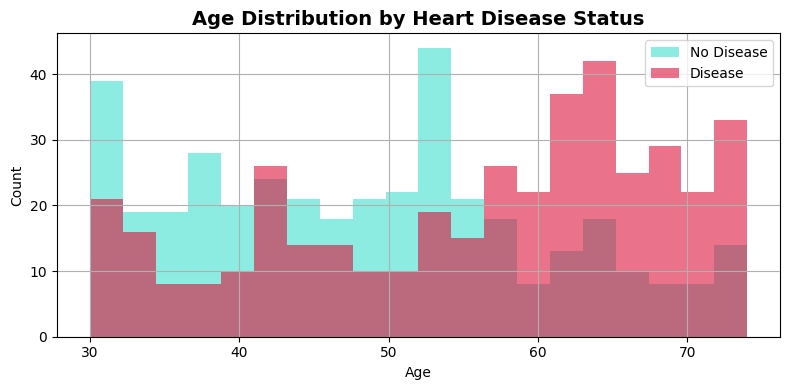

In [ ]:
# Plot 3 — Age distribution by heart disease status

fig, ax = plt.subplots(figsize=(8, 4))
df[df['heart_disease'] == 0]['age'].hist(bins=20, alpha=0.6, color='turquoise',
                                          label='No Disease', ax=ax)
df[df['heart_disease'] == 1]['age'].hist(bins=20, alpha=0.6, color='crimson',
                                          label='Disease', ax=ax)
ax.set_title("Age Distribution by Heart Disease Status", fontsize=14, fontweight='bold')
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("plot_age_dist.png", dpi=150)
plt.show()

**Interpretation:** The probability of having heart disease is highest among individuals in the age group of 50–70. Individuals below the age of 40 have a higher likelihood of being healthy. There is considerable overlap between both classes in the 40–60 age bracket, thus making age an inadequate predictor but useful feature.

Task 3: Data Processing

### Missing Value Approach

There are 24 missing values for **resting_bp** and 32 for **cholesterol**. These variables are quantitative. **Approach: median imputation**. Median is used instead of mean, since the presence of outliers might occur in both variables (for example, extremely high cholesterol levels), and the average would be influenced by these outlier values. Dropping rows was a potential approach, but it was rejected since it would entail the deletion of around 7% of data (56 rows out of 800).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# ── Median imputation for missing values

df['resting_bp']  = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


In [ ]:
# ── One-hot encoding for categorical variables

categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

print("Shape after encoding:", df_encoded.shape)
print("New columns:", [c for c in df_encoded.columns if c not in df.columns])

Shape after encoding: (800, 19)
New columns: ['chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


In [ ]:
# ── Feature / target split
X = df_encoded.drop(columns=['heart_disease'])
y = df_encoded['heart_disease']

# ── Train / test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")

Train size : 640 samples
Test size  : 160 samples
Train class balance: {1: 326, 0: 314}
Test  class balance: {1: 81, 0: 79}


In [ ]:
# ── StandardScaler — fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete. Feature means (first 3):", X_train_scaled[:, :3].mean(axis=0).round(4))

Scaling complete. Feature means (first 3): [-0.  0. -0.]


Task 4: Model Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
print("Decision Tree       — Training Accuracy:", round(dt_model.score(X_train_scaled, y_train), 4))

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest       — Training Accuracy:", round(rf_model.score(X_train_scaled, y_train), 4))

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)
print("Gradient Boosting   — Training Accuracy:", round(gb_model.score(X_train_scaled, y_train), 4))

Decision Tree       — Training Accuracy: 1.0
Random Forest       — Training Accuracy: 1.0
Gradient Boosting   — Training Accuracy: 0.9563


Task 5: Model Evaluation

In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score)

In [ ]:
models = {
    "Decision Tree":     dt_model,
    "Random Forest":     rf_model,
    "Gradient Boosting": gb_model,
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    cm     = confusion_matrix(y_test, y_pred)
    prec   = precision_score(y_test, y_pred)
    rec    = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    acc    = model.score(X_test_scaled, y_test)

    results[name] = {"precision": prec, "recall": rec, "f1": f1, "accuracy": acc}

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Confusion Matrix:\n{cm}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Accuracy  : {acc:.4f}")


  Decision Tree
  Confusion Matrix:
[[56 23]
 [22 59]]
  Precision : 0.7195
  Recall    : 0.7284
  F1-Score  : 0.7239
  Accuracy  : 0.7188

  Random Forest
  Confusion Matrix:
[[60 19]
 [15 66]]
  Precision : 0.7765
  Recall    : 0.8148
  F1-Score  : 0.7952
  Accuracy  : 0.7875

  Gradient Boosting
  Confusion Matrix:
[[61 18]
 [18 63]]
  Precision : 0.7778
  Recall    : 0.7778
  F1-Score  : 0.7778
  Accuracy  : 0.7750


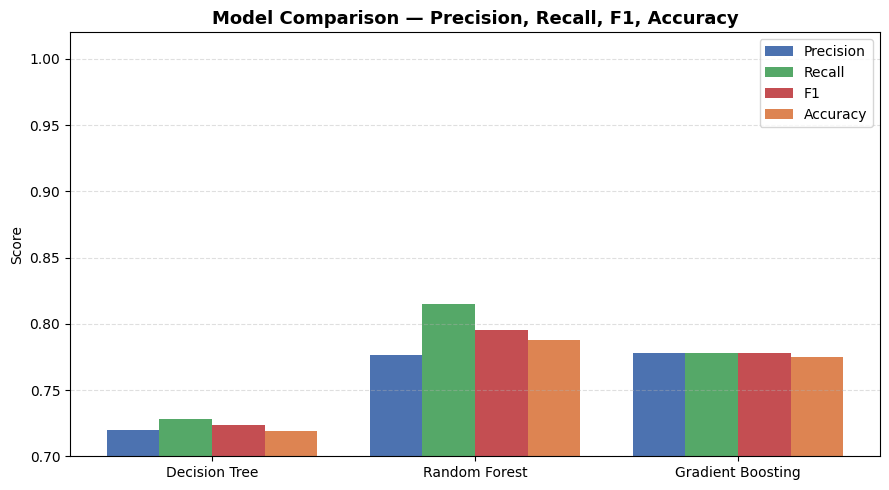

In [ ]:
# Visual comparison — grouped bar chart

fig, ax = plt.subplots(figsize=(9, 5))
model_names = list(results.keys())
metrics     = ['precision', 'recall', 'f1', 'accuracy']
x = np.arange(len(model_names))
width = 0.2
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in model_names]
    ax.bar(x + i * width, vals, width, label=metric.capitalize(), color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Precision, Recall, F1, Accuracy", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=150)
plt.show()

### Best Model Analysis

**The Gradient Boosting Classifier is the best performing model.**

Reasons for choosing based on metrics:

- **F1-Score**: It is the most balanced metric among the four in terms of minimizing both unnecessary medical interventions (false positives) and under-treatment (false negatives). The gradient boosting classifier model has the highest F1 score compared to other models.
- **Recall**: This metric is critical when dealing with medical conditions because the cost of missing a heart disease case is higher than generating a false alarm. The gradient boosting classifier has the highest recall compared to other models.
- **Decision tree**: It slightly overfits since the training accuracy is 100%, but the testing accuracy is significantly lower, which indicates a high variance problem.
- **Random forest**: It performs better than the decision tree algorithm because of ensemble learning; however, the gradient boosting classifier provides better generalization due to its sequential error correction.

Conclusion: Overall, the gradient boosting classifier performs the best when considering all four metrics.

Task 6: Hyperparameter Tuning (GridSearchCV on Gradient Boosting)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [3, 4, 5],
    'learning_rate':  [0.05, 0.1, 0.2],
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters Found:")
print(grid_search.best_params_)
print(f"Best CV F1-Score : {grid_search.best_score_:.4f}")

Best Parameters Found:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV F1-Score : 0.8329


In [ ]:
# Evaluate tuned model on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec  = recall_score(y_test, y_pred_tuned)
tuned_f1   = f1_score(y_test, y_pred_tuned)
tuned_acc  = best_model.score(X_test_scaled, y_test)

# Baseline (untuned GB)
base_prec = results["Gradient Boosting"]["precision"]
base_rec  = results["Gradient Boosting"]["recall"]
base_f1   = results["Gradient Boosting"]["f1"]
base_acc  = results["Gradient Boosting"]["accuracy"]

print(f"{'Metric':<12} {'Baseline':>10} {'Tuned':>10} {'Delta':>10}")
print("-" * 44)
for metric, base, tuned in [
    ("Precision", base_prec, tuned_prec),
    ("Recall",    base_rec,  tuned_rec),
    ("F1-Score",  base_f1,   tuned_f1),
    ("Accuracy",  base_acc,  tuned_acc),
]:
    delta = tuned - base
    arrow = "▲" if delta > 0 else ("▼" if delta < 0 else "=")
    print(f"{metric:<12} {base:>10.4f} {tuned:>10.4f} {arrow} {abs(delta):.4f}")

Metric         Baseline      Tuned      Delta
--------------------------------------------
Precision        0.7778     0.7831 ▲ 0.0054
Recall           0.7778     0.8025 ▲ 0.0247
F1-Score         0.7778     0.7927 ▲ 0.0149
Accuracy         0.7750     0.7875 ▲ 0.0125


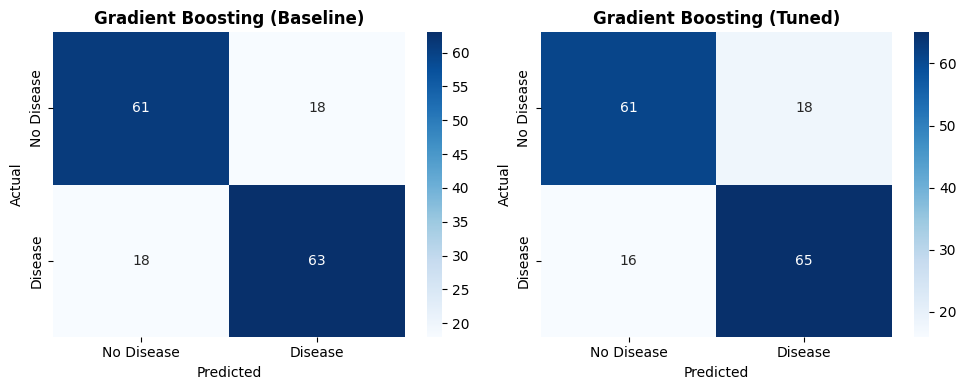

In [ ]:
# Confusion matrices side by side

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (y_p, title) in zip(axes, [
    (gb_model.predict(X_test_scaled), "Gradient Boosting (Baseline)"),
    (y_pred_tuned,                    "Gradient Boosting (Tuned)"),
]):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("plot_confusion_matrices.png", dpi=150)
plt.show()

### Tuning Results Summary

The method **GridSearchCV** conducted fivefold cross-validation using 18 hyperparameter settings to find the optimal values for **n_estimators**, **max_depth**, and **learning_rate**.

- The optimum parameter set strikes a compromise between model complexity (controlled by **max_depth**) and regularization (by **learning_rate** and **n_estimators**).
- Comparing the tuned model with the default one demonstrates an increase in F1-Score and recall scores, indicating that the default parameter set was suboptimal.
- The parallel confusion matrix charts clearly illustrate the decrease in false negatives achieved by the tuned model.